# AdaBoost Regression
### What is AdaBoost?

**AdaBoost** stands for **Adaptive Boosting**. It is a boosting algorithm that combines several weak learners (simple models) into one strong learner.

The key idea is simple:
- Train a weak model on the data
- Find the samples where the model made large errors
- Give those samples more importance (higher weight) in the next round
- Repeat this process many times
- Combine all the weak models into one final strong model

### How it works 

1. Start with equal weights for all training samples
2. Train a weak model (usually a Decision Stump - a tree with depth 1)
3. Identify samples where the model predicted poorly
4. Increase the weight of those poorly predicted samples
5. Train the next weak model on this re-weighted data
6. Repeat steps 3-5 for N estimators
7. Final prediction = weighted combination of all weak model predictions

### AdaBoost for Regression

In regression, AdaBoost:
- Uses `DecisionTreeRegressor` as the base learner
- Adjusts sample weights based on **residual errors** (how far off the prediction was)
- Combines weak learners using weighted median or weighted average


### Import Required Libraries

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load and Explore the Dataset

Use the **California Housing Dataset** from scikit-learn.

- **Task**: Predict median house prices
- **Features**: 8 numerical features (income, house age, rooms, etc.)
- **Target**: Median house value (in units of $100,000)

In [66]:
# Load the dataset
housing = fetch_california_housing()

# Convert to a DataFrame for easy viewing
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target_Price'] = housing.target

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target_Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [67]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Missing values per column:
MedInc          0
HouseAge        0
AveRooms        0
AveBedrms       0
Population      0
AveOccup        0
Latitude        0
Longitude       0
Target_Price    0
dtype: int64

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target_Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Prepare the Data

Split the data into:
- **X** : Feature columns (input)
- **y** : Target column (output we want to predict)

Then split into training and testing sets.

In [69]:
# Separate features (X) and target (y)
X = df.drop('Target_Price', axis=1)   
y = df['Target_Price']                 

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16512
Testing samples : 4128


### Feature Scaling

In [71]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data (do not fit again)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("X_train_scaled shape:", X_train_scaled.shape)

Scaling done.
X_train_scaled shape: (16512, 8)


### Build and Train the AdaBoost Regressor

### Key Parameters 

| Parameter | What it means |
|-----------|---------------|
| `estimator` | The weak learner used in each round. Default is DecisionTreeRegressor with max_depth=3 |
| `n_estimators` | Number of weak learners (boosting rounds). More = better, but slower |
| `learning_rate` | How much each weak learner contributes. Lower = more conservative learning |
| `loss` | Error function used to update weights. Options: 'linear', 'square', 'exponential' |
| `random_state` | For reproducibility |

In [100]:
# Define the base learner
# max_depth=3 means a shallow tree -> a "weak" learner
base_learner = DecisionTreeRegressor(max_depth=3)

# Build the AdaBoost Regressor
ada_model = AdaBoostRegressor(
    estimator=base_learner,    # Weak learner
    n_estimators=100,          # Number of boosting rounds
    learning_rate=0.1,         # Step size (shrinkage)
    loss='linear',             # Loss function for weight update
    random_state=42
)

# Train the model on training data
ada_model.fit(X_train_scaled, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3),
                  learning_rate=0.1, n_estimators=100, random_state=42)

### Make Predictions

In [75]:
# Predict on test data
y_pred = ada_model.predict(X_test_scaled)

# Preview actual vs predicted values
results = pd.DataFrame({'Actual'   : y_test.values[:10], 'Predicted': y_pred[:10].round(3) })

print("Sample Predictions (first 10):")
print(results)

Sample Predictions (first 10):
    Actual  Predicted
0  0.47700      1.540
1  0.45800      1.540
2  5.00001      3.090
3  2.18600      2.561
4  2.78000      2.292
5  1.58700      2.364
6  1.98200      2.479
7  1.57500      1.990
8  3.40000      3.153
9  4.46600      3.973


### Evaluate the Model
- **MSE** 
- **RMSE** 
- **MAE** 
- **R2 Score** 

In [77]:
# Calculate evaluation metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print(f"Mean Squared Error  (MSE)  : {mse:.4f}")
print(f"Root Mean Sq Error  (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Error (MAE)  : {mae:.4f}")
print(f"R2 Score                   : {r2:.4f}")

Model Evaluation Results
Mean Squared Error  (MSE)  : 0.5691
Root Mean Sq Error  (RMSE) : 0.7544
Mean Absolute Error (MAE)  : 0.6078
R2 Score                   : 0.5657


### Visualize Results - Actual vs Predicted Values


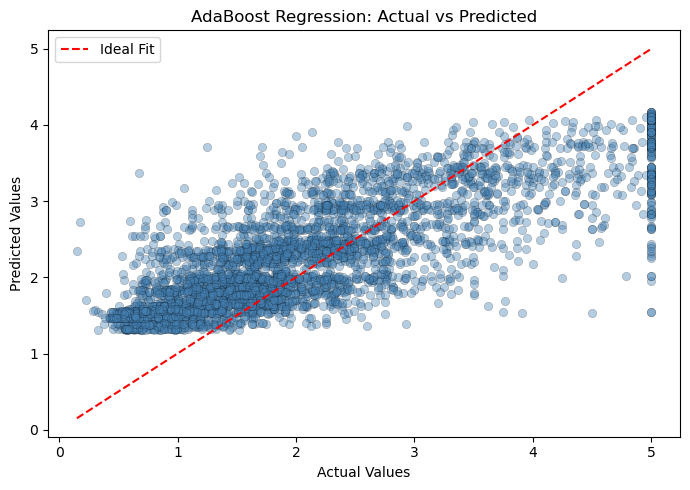

In [79]:
plt.figure(figsize=(7, 5))

# Scatter plot: actual on x-axis, predicted on y-axis
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)

# Draw the ideal line (perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=1.5, linestyle='--', label='Ideal Fit')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('AdaBoost Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Residuals Plot

**Residual** = Actual - Predicted

- Points close to 0 = good predictions
- Random scatter around 0 = no systematic error (good sign)
- A pattern in residuals = the model is missing something

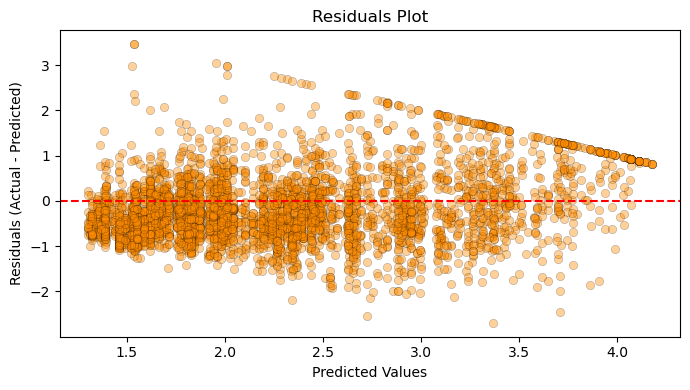

In [81]:
# Calculate residuals
residuals = y_test.values - y_pred

plt.figure(figsize=(7, 4))

plt.scatter(y_pred, residuals, alpha=0.4, color='darkorange', edgecolors='k', linewidths=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)   

plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals Plot')
plt.tight_layout()
plt.show()

### Feature Importances

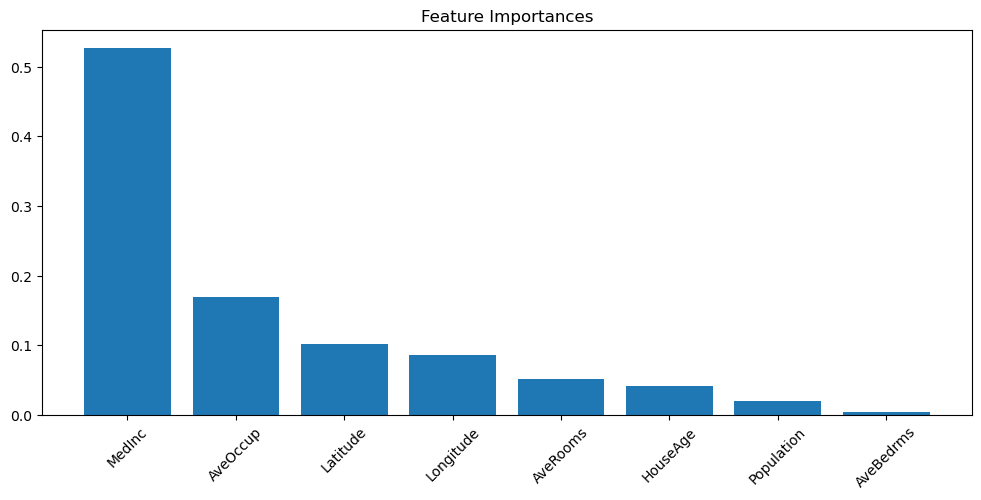

In [83]:
# Get feature importance
importances = ada_model.feature_importances_

# Sort indices
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=45)
plt.title("Feature Importances")
plt.show()